# Heart Health Dataset: Visualization & Exploratory Analysis
## BRFSS 2015 Heart Disease Health Indicators

### Project Overview & Purpose
This notebook builds a comprehensive set of visualizations on top of the cleaned and
feature-engineered dataset produced in `Heart_Health_Data_Cleaning.ipynb`
(`data/heart_disease_cleaned.csv`). The goal is to visually explore categorical
variables, compare heart disease prevalence across categories, examine the
distributions of continuous variables, and investigate relationships between
variables using a broad set of chart types:

1. Bar charts and pie charts for categorical variables
2. Grouped and stacked bar charts comparing heart disease across categories
3. Histograms and box plots for continuous variable distributions
4. A correlation heatmap across key numeric variables
5. Scatter plots investigating relationships between variables
6. Line plots showing trends across ordered categories
7. Violin plots combining distribution shape and summary statistics
8. A pair plot showing pairwise relationships across multiple variables

All figures are saved to the `visuals/` folder as PNG files so they can be reused in
later reporting stages (Word document, presentation, etc.).

---

### Step 1: Environment Setup & Library Imports

**Why this is being done (Logic):**
Before building any visualizations, we need to load the Python libraries responsible
for data handling (`pandas`, `numpy`) and chart creation (`matplotlib`, `seaborn`).
We also need the `os` library to manage the folder where figures will be saved.

**How it is being done (Code Explanation):**
- `import pandas as pd`: Imports Pandas for reading and manipulating the cleaned dataset.
- `import numpy as np`: Imports NumPy for numerical operations such as correlation and jitter.
- `import matplotlib.pyplot as plt`: Imports the core plotting library.
- `import seaborn as sns`: Imports Seaborn, which sits on top of Matplotlib and provides
  statistical chart types such as heatmaps, violin plots, and pair plots.
- `import os`: Used to create the `visuals` output folder.
- `plt.style.use(...)` and `plt.rcParams.update(...)`: Applies a clean, professional
  default look (white grid background, consistent font sizes) across every chart in
  this notebook, so we do not need to repeat these settings figure by figure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# Suppress non-critical warnings for clean notebook output
warnings.filterwarnings('ignore')

# Set display options for clean output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Apply a clean, professional default chart style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 15,
})

print("Environment successfully setup with Pandas version:", pd.__version__)
print("Environment successfully setup with Seaborn version:", sns.__version__)

Environment successfully setup with Pandas version: 3.0.2
Environment successfully setup with Seaborn version: 0.13.2


### Step 2: Defining the "Teal Trust" Color Palette

**Why this is being done (Logic):**
To keep this notebook visually consistent with the Stage 3 EDA presentation, all
charts in this notebook reuse the same "Teal Trust" healthcare color palette. Using
one fixed palette across every chart also follows good design practice: color should
be used consistently and purposefully, not chosen ad hoc for each figure.

**How it is being done (Code Explanation):**
- We store the palette as a plain Python dictionary, `teal_trust_palette`, with named
  colors (`teal`, `navy`, `coral`, `blue`, `grey`, `green`, `purple`).
- `no_yes_palette`: A two-color list specifically for "No" vs "Yes" heart disease
  comparisons (blue for No, coral for Yes), matching the Stage 3 presentation.
- Naming the colors instead of using raw hex codes throughout the notebook makes the
  later chart code easier to read (e.g. `teal_trust_palette['teal']` instead of an
  unlabeled hex string).

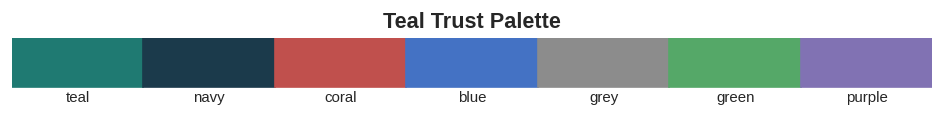

In [2]:
# Named "Teal Trust" healthcare color palette (reused from the Stage 3 presentation)
teal_trust_palette = {
    'teal': '#1F7A72',
    'navy': '#1B3A4B',
    'coral': '#C0504D',
    'blue': '#4472C4',
    'grey': '#8C8C8C',
    'green': '#55A868',
    'purple': '#8172B3',
}

# Two-color palette specifically for No / Yes heart disease comparisons
no_yes_palette = [teal_trust_palette['blue'], teal_trust_palette['coral']]

# Preview the palette as small color swatches
figure_palette, axis_palette = plt.subplots(figsize=(8, 1.2))
color_names = list(teal_trust_palette.keys())
color_position = 0

for color_name in color_names:
    axis_palette.add_patch(plt.Rectangle((color_position, 0), 1, 1, color=teal_trust_palette[color_name]))
    axis_palette.text(color_position + 0.5, -0.3, color_name, ha='center', fontsize=9)
    color_position = color_position + 1

axis_palette.set_xlim(0, color_position)
axis_palette.set_ylim(-0.6, 1)
axis_palette.axis('off')
axis_palette.set_title('Teal Trust Palette', fontweight='bold')
plt.tight_layout()
plt.show()

### Step 3: Loading the Cleaned Dataset & Creating the Output Folder

**Why this is being done (Logic):**
This notebook visualizes the dataset produced by the Stage 2 cleaning notebook, so we
load it directly from `data/heart_disease_cleaned.csv` rather than the raw survey
file. We also create a dedicated `visuals` folder up front so every figure created
later in the notebook has a consistent place to be saved.

**How it is being done (Code Explanation):**
- `pd.read_csv(...)`: Reads the cleaned CSV file into a DataFrame named `df`.
- `df.shape`: Confirms the number of rows and columns loaded.
- `os.makedirs('visuals', exist_ok=True)`: Creates the `visuals` output folder if it
  does not already exist, without raising an error if it does.

In [3]:
# Load the cleaned dataset produced in the Stage 2 notebook
cleaned_csv_path = os.path.join('..', 'data', 'heart_disease_cleaned.csv')
df = pd.read_csv(cleaned_csv_path)

# Create the output folder for saved figures
visuals_dir = os.path.join('..', 'visuals')
os.makedirs(visuals_dir, exist_ok=True)

print(f"Cleaned Dataset Shape: {df.shape[0]:,} rows and {df.shape[1]} columns")
df.head()

Cleaned Dataset Shape: 229,781 rows and 45 columns


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Sex_Label,Diabetes_Status,General_Health,Age_Category,Education_Level,Income_Bracket,Heart_Disease_or_Attack,High_BP_Label,High_Cholesterol_Label,Cholesterol_Check_5yrs,Smoker_Status,Stroke_History,Physical_Activity,Fruit_Consump_Daily,Veggie_Consump_Daily,Heavy_Alcohol_Consump,Healthcare_Coverage,No_Doctor_Due_To_Cost,Difficulty_Walking,BMI_Category,Age_Group_Broad,Total_Unhealthy_Days,Cardiovascular_Risk_Score
0,0,1,1,1,40,1,0,0,0,0,1,0,1,0,5,18,15,1,0,9,4,3,Female,No Diabetes,5 - Poor,60-64,Grade 12 / GED (High School Grad),"$15,000 to < $20,000",No,Yes,Yes,Yes,Yes,No,No,No,Yes,No,Yes,No,Yes,Obese,Older Adults (60+),33,4
1,0,0,0,0,25,1,0,0,1,0,0,0,0,1,3,0,0,0,0,7,6,1,Female,No Diabetes,3 - Good,50-54,College 4+ yrs (College Grad),"Less than $10,000",No,No,No,No,Yes,No,Yes,No,No,No,No,Yes,No,Overweight,Middle-Aged Adults (40-59),0,1
2,0,1,1,1,28,0,0,0,0,1,0,0,1,1,5,30,30,1,0,9,4,8,Female,No Diabetes,5 - Poor,60-64,Grade 12 / GED (High School Grad),"$75,000 or more",No,Yes,Yes,Yes,No,No,No,Yes,No,No,Yes,Yes,Yes,Overweight,Older Adults (60+),60,3
3,0,1,0,1,27,0,0,0,1,1,1,0,1,0,2,0,0,0,0,11,3,6,Female,No Diabetes,2 - Very Good,70-74,Grades 9-11 (Some High School),"$35,000 to < $50,000",No,Yes,No,Yes,No,No,Yes,Yes,Yes,No,Yes,No,No,Overweight,Older Adults (60+),0,1
4,0,1,1,1,24,0,0,0,1,1,1,0,1,0,2,3,0,0,0,11,5,4,Female,No Diabetes,2 - Very Good,70-74,College 1-3 yrs (Some College / Tech),"$20,000 to < $25,000",No,Yes,Yes,Yes,No,No,Yes,Yes,Yes,No,Yes,No,No,Normal Weight,Older Adults (60+),3,2


## Section 1: Visualizing Categorical Variables (Bar Charts & Pie Charts)

### Step 4: Distribution of Lifestyle Categorical Variables

**Why this is being done (Logic):**
Before comparing lifestyle habits to heart disease outcomes, we first need to see how
common each habit is on its own. `Smoker_Status`, `Physical_Activity`,
`Fruit_Consump_Daily`, and `Veggie_Consump_Daily` are all Yes/No categorical labels
created during Stage 2 cleaning. A bar chart shows exact counts, while a pie chart
shows the same information as a share of the whole sample — together they give a
complete picture of each variable's distribution.

**How it is being done (Code Explanation):**
- `lifestyle_columns`: A plain list of the four categorical column names to visualize.
- We build one figure with 2 rows x 4 columns of subplots: the top row holds bar
  charts, the bottom row holds pie charts for the same four variables.
- A `for` loop with an index variable steps through `lifestyle_columns` one at a time.
- `df[column_name].value_counts()`: Counts how many respondents fall into each
  category ("Yes" / "No") for the current column.
- `axis_bar.bar(...)`: Draws the bar chart using the counted values.
- `axis_pie.pie(...)`: Draws the matching pie chart using the same counted values.
- `plt.savefig(...)`: Saves the completed figure to the `visuals` folder as a PNG.

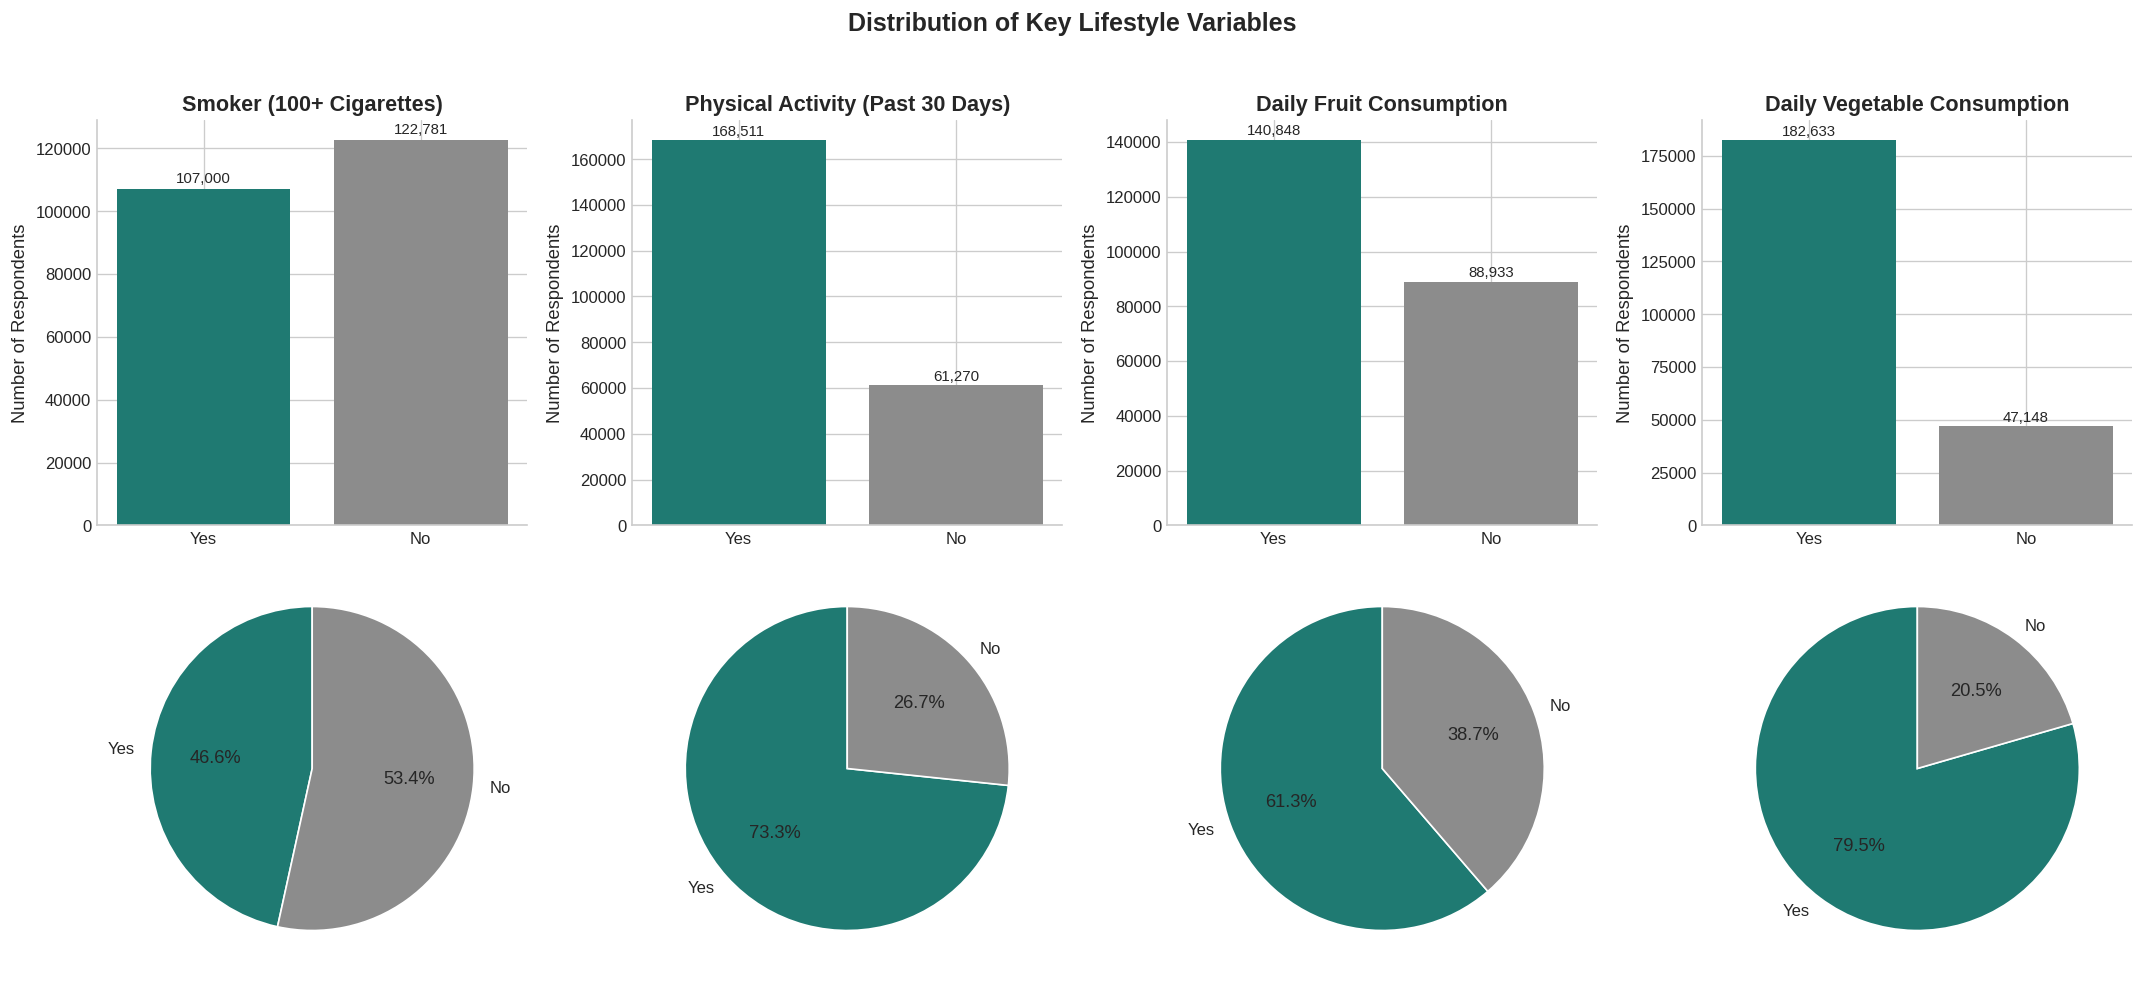

In [4]:
# List of lifestyle categorical variables to visualize
lifestyle_columns = ['Smoker_Status', 'Physical_Activity', 'Fruit_Consump_Daily', 'Veggie_Consump_Daily']
lifestyle_titles = ['Smoker (100+ Cigarettes)', 'Physical Activity (Past 30 Days)', 'Daily Fruit Consumption', 'Daily Vegetable Consumption']

# Build a 2-row x 4-column figure: bar charts on top, pie charts on bottom
figure_categorical, axis_grid = plt.subplots(2, 4, figsize=(18, 8))

column_index = 0
while column_index < len(lifestyle_columns):

    current_column = lifestyle_columns[column_index]
    current_title = lifestyle_titles[column_index]

    # Count how many respondents answered "Yes" vs "No" for this column,
    # then reindex to a fixed ['Yes', 'No'] order so colors stay consistent across panels
    category_counts = df[current_column].value_counts()
    category_counts = category_counts.reindex(['Yes', 'No'])
    category_labels = category_counts.index
    category_values = category_counts.values

    # Bar chart on the top row (Yes is always teal, No is always grey)
    axis_bar = axis_grid[0, column_index]
    bar_colors = [teal_trust_palette['teal'], teal_trust_palette['grey']]
    axis_bar.bar(category_labels, category_values, color=bar_colors[:len(category_labels)])
    axis_bar.set_title(current_title)
    axis_bar.set_ylabel('Number of Respondents')
    for label_position in range(len(category_values)):
        axis_bar.text(label_position, category_values[label_position] + 2000,
                       f'{category_values[label_position]:,}', ha='center', fontsize=9)
    axis_bar.spines['top'].set_visible(False)
    axis_bar.spines['right'].set_visible(False)

    # Pie chart on the bottom row, using the same counts
    axis_pie = axis_grid[1, column_index]
    axis_pie.pie(category_values, labels=category_labels, autopct='%1.1f%%',
                 colors=bar_colors[:len(category_labels)], startangle=90,
                 wedgeprops={'edgecolor': 'white', 'linewidth': 1})

    column_index = column_index + 1

figure_categorical.suptitle('Distribution of Key Lifestyle Variables', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(visuals_dir, '01_categorical_lifestyle_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

**Findings / Insights:**
- **Smoking** is close to an even split: 46.6% of respondents report a smoking history
  of 100+ cigarettes, versus 53.4% who do not.
- **Physical activity** is common — 73.3% report some physical activity in the past 30
  days, leaving 26.7% who report none.
- **Fruit consumption** is the least consistent healthy habit shown here: only 61.3%
  report eating fruit at least once a day.
- **Vegetable consumption** is the most consistent healthy habit: 79.5% report daily
  vegetable intake, the highest "Yes" share of the four variables.

## Section 2: Comparing Heart Disease Prevalence Across Categories

### Step 5: Grouped Bar Charts — Lifestyle Variables vs. Heart Disease

**Why this is being done (Logic):**
Knowing how common a habit is on its own is only half the picture — the more useful
question is whether that habit is associated with a higher or lower rate of heart
disease. A grouped bar chart lets us compare the heart disease prevalence rate for
"Yes" respondents against "No" respondents, side by side, for each lifestyle variable.

**How it is being done (Code Explanation):**
- We reuse `lifestyle_columns` from Step 4.
- For each column, `pd.crosstab(..., normalize='index')` builds a small table showing
  what percentage of each category ("Yes"/"No") does and does not have heart disease.
- We build one figure with 1 row x 4 columns, one grouped bar chart per variable.
- `axis.bar(...)` is called twice per subplot (once for "No" heart disease, once for
  "Yes"), with the bar positions offset using `bar_width` so the two bars for each
  category sit side by side instead of overlapping.

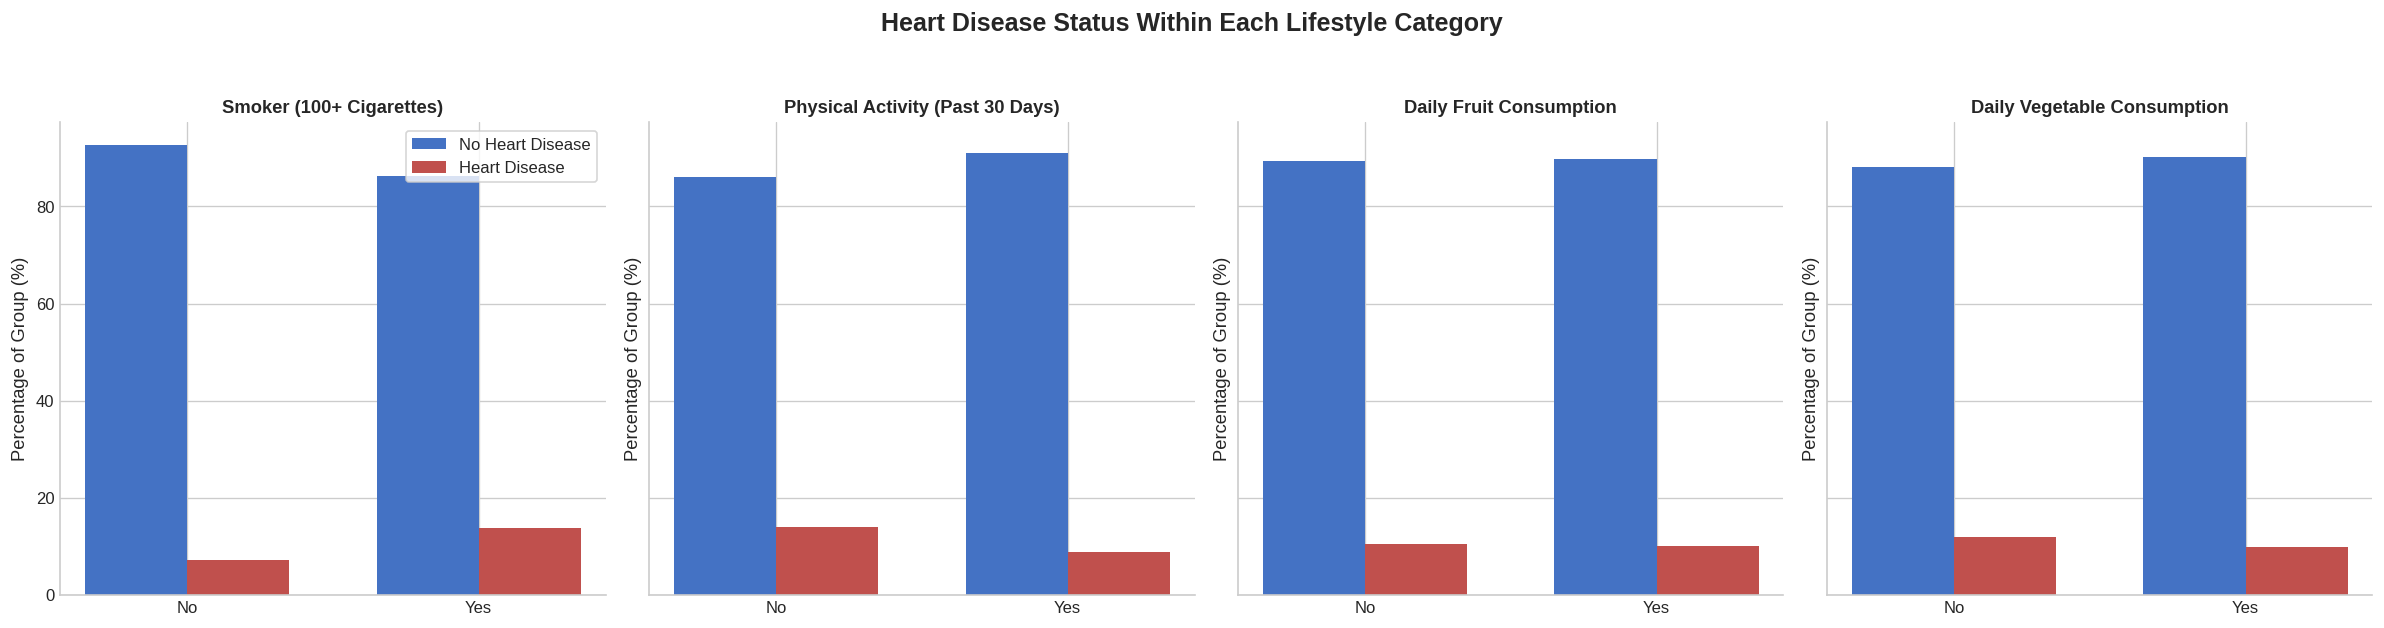

In [5]:
# Build a 1-row x 4-column figure: one grouped bar chart per lifestyle variable
figure_grouped, axis_grouped_grid = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

bar_width = 0.35
column_index = 0

while column_index < len(lifestyle_columns):

    current_column = lifestyle_columns[column_index]
    current_title = lifestyle_titles[column_index]

    # Cross-tabulate the current column against heart disease status, as row percentages
    crosstab_result = pd.crosstab(df[current_column], df['Heart_Disease_or_Attack'], normalize='index') * 100

    category_labels = crosstab_result.index
    bar_positions = np.arange(len(category_labels))

    no_heart_disease_pct = crosstab_result['No']
    yes_heart_disease_pct = crosstab_result['Yes']

    axis_grouped = axis_grouped_grid[column_index]
    axis_grouped.bar(bar_positions - bar_width / 2, no_heart_disease_pct, width=bar_width,
                      label='No Heart Disease', color=no_yes_palette[0])
    axis_grouped.bar(bar_positions + bar_width / 2, yes_heart_disease_pct, width=bar_width,
                      label='Heart Disease', color=no_yes_palette[1])

    axis_grouped.set_xticks(bar_positions)
    axis_grouped.set_xticklabels(category_labels)
    axis_grouped.set_title(current_title, fontsize=11)
    axis_grouped.set_ylabel('Percentage of Group (%)')
    axis_grouped.spines['top'].set_visible(False)
    axis_grouped.spines['right'].set_visible(False)

    column_index = column_index + 1

axis_grouped_grid[0].legend(loc='upper right', frameon=True)
figure_grouped.suptitle('Heart Disease Status Within Each Lifestyle Category', fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(os.path.join(visuals_dir, '02_grouped_bar_lifestyle_vs_heart_disease.png'), dpi=150, bbox_inches='tight')
plt.show()

**Findings / Insights:**
- **Smoking** shows the widest gap of the four: 13.7% of smokers have heart disease
  versus 7.3% of non-smokers — almost double the prevalence.
- **Physical activity** shows a protective pattern: 9.0% prevalence among the
  physically active versus 14.0% among the inactive.
- **Fruit consumption** shows almost no separation (10.1% vs. 10.6%), making it the
  weakest of the four lifestyle variables for distinguishing heart disease status on
  its own.
- **Vegetable consumption** shows a modest gap: 9.9% prevalence among daily vegetable
  eaters versus 12.0% among those who eat vegetables less often.
- Overall, smoking and physical activity separate the two groups more clearly than
  fruit or vegetable intake do, at least as single variables.

### Step 6: Stacked Bar Chart — Heart Disease Composition by General Health Rating

**Why this is being done (Logic):**
A stacked bar chart is useful when we want to show, within each category, what
proportion is made up of each outcome — in this case, what share of each
self-reported general health rating (`General_Health`) consists of respondents with
and without heart disease. This highlights how the "No" / "Yes" split shifts as
self-rated health worsens.

**How it is being done (Code Explanation):**
- `pd.crosstab(..., normalize='index')`: Builds a percentage table of heart disease
  status within each general health rating.
- `sort_index()`: Keeps the health ratings in their natural order (Excellent to Poor)
  rather than alphabetical order, since the labels already start with a leading
  number (e.g. `'1 - Excellent'`).
- `axis.bar(...)` is called twice: the second call passes `bottom=no_heart_disease_pct`
  so the "Yes" segment stacks on top of the "No" segment instead of overlapping it.

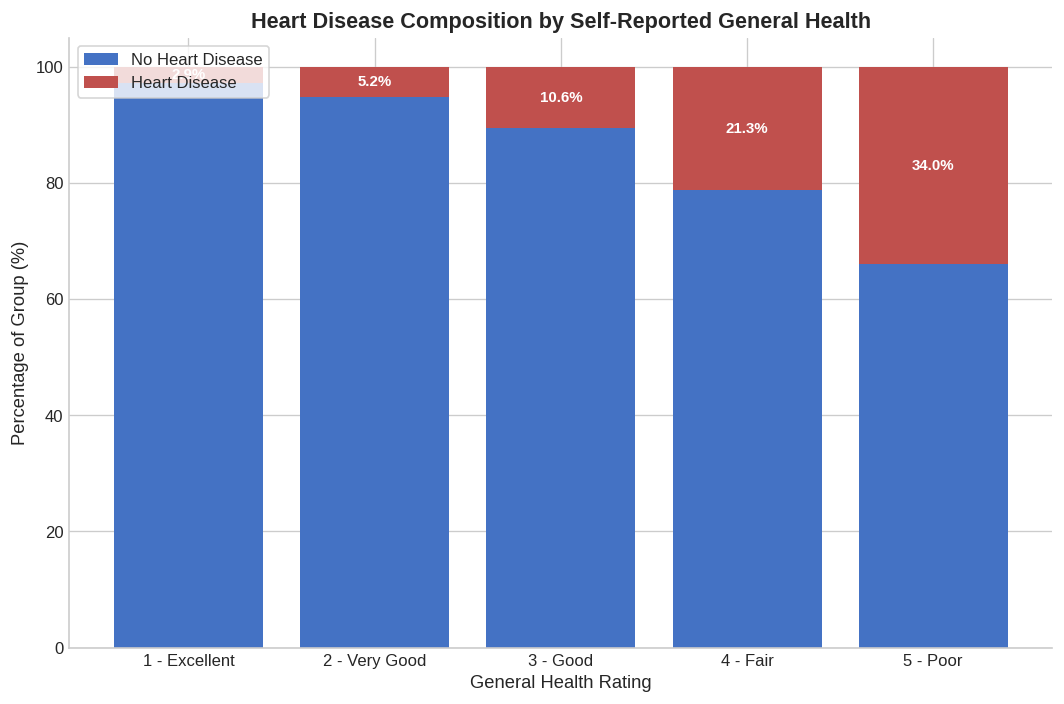

In [6]:
# Cross-tabulate General Health rating against heart disease status, as row percentages
genhlth_crosstab = pd.crosstab(df['General_Health'], df['Heart_Disease_or_Attack'], normalize='index') * 100
genhlth_crosstab = genhlth_crosstab.sort_index()

health_rating_labels = genhlth_crosstab.index
no_heart_disease_pct = genhlth_crosstab['No']
yes_heart_disease_pct = genhlth_crosstab['Yes']

figure_stacked, axis_stacked = plt.subplots(figsize=(9, 6))

axis_stacked.bar(health_rating_labels, no_heart_disease_pct, label='No Heart Disease', color=no_yes_palette[0])
axis_stacked.bar(health_rating_labels, yes_heart_disease_pct, bottom=no_heart_disease_pct,
                  label='Heart Disease', color=no_yes_palette[1])

# Label the "Heart Disease" segment with its percentage for readability
rating_index = 0
while rating_index < len(health_rating_labels):
    segment_height = yes_heart_disease_pct.iloc[rating_index]
    segment_bottom = no_heart_disease_pct.iloc[rating_index]
    axis_stacked.text(rating_index, segment_bottom + segment_height / 2, f'{segment_height:.1f}%',
                       ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    rating_index = rating_index + 1

axis_stacked.set_title('Heart Disease Composition by Self-Reported General Health', fontweight='bold')
axis_stacked.set_xlabel('General Health Rating')
axis_stacked.set_ylabel('Percentage of Group (%)')
axis_stacked.legend(loc='upper left', frameon=True)
axis_stacked.spines['top'].set_visible(False)
axis_stacked.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(visuals_dir, '03_stacked_bar_genhlth_vs_heart_disease.png'), dpi=150, bbox_inches='tight')
plt.show()

**Findings / Insights:**
- Heart disease prevalence climbs steadily and consistently as self-reported general
  health worsens: 2.9% among respondents who rate their health "Excellent," rising to
  34.0% among those who rate it "Poor."
- The jump is largest between the "Good" and "Fair" ratings (10.6% to 21.3%), and
  again between "Fair" and "Poor" (21.3% to 34.0%) — the two worst self-reported
  health tiers carry a disproportionate share of heart disease cases.
- Because this is a simple self-reported single question, it is a strikingly strong
  and easy-to-collect signal for heart disease risk.

## Section 3: Distributions of Continuous Variables

### Step 7: Histograms & Box Plots — BMI, Mental Health Days, Physical Health Days

**Why this is being done (Logic):**
`BMI`, `MentHlth` (poor mental health days in the past 30 days), and `PhysHlth` (poor
physical health days in the past 30 days) are the three continuous variables in this
dataset. A histogram shows the overall shape of each distribution (e.g. skew, common
values), while a box plot summarizes the same distribution using the median,
quartiles, and outliers. Showing both side by side gives a fuller picture than either
chart alone.

**How it is being done (Code Explanation):**
- `continuous_columns`: A plain list of the three continuous column names.
- We build a 2-row x 3-column figure: histograms on the top row, box plots on the
  bottom row, one column per variable.
- `axis_hist.hist(...)`: Draws the histogram with a fixed number of bins.
- `axis_hist.axvline(...)`: Adds vertical reference lines for the mean and median.
- `axis_box.boxplot(...)`: Draws the matching box plot for the same variable.

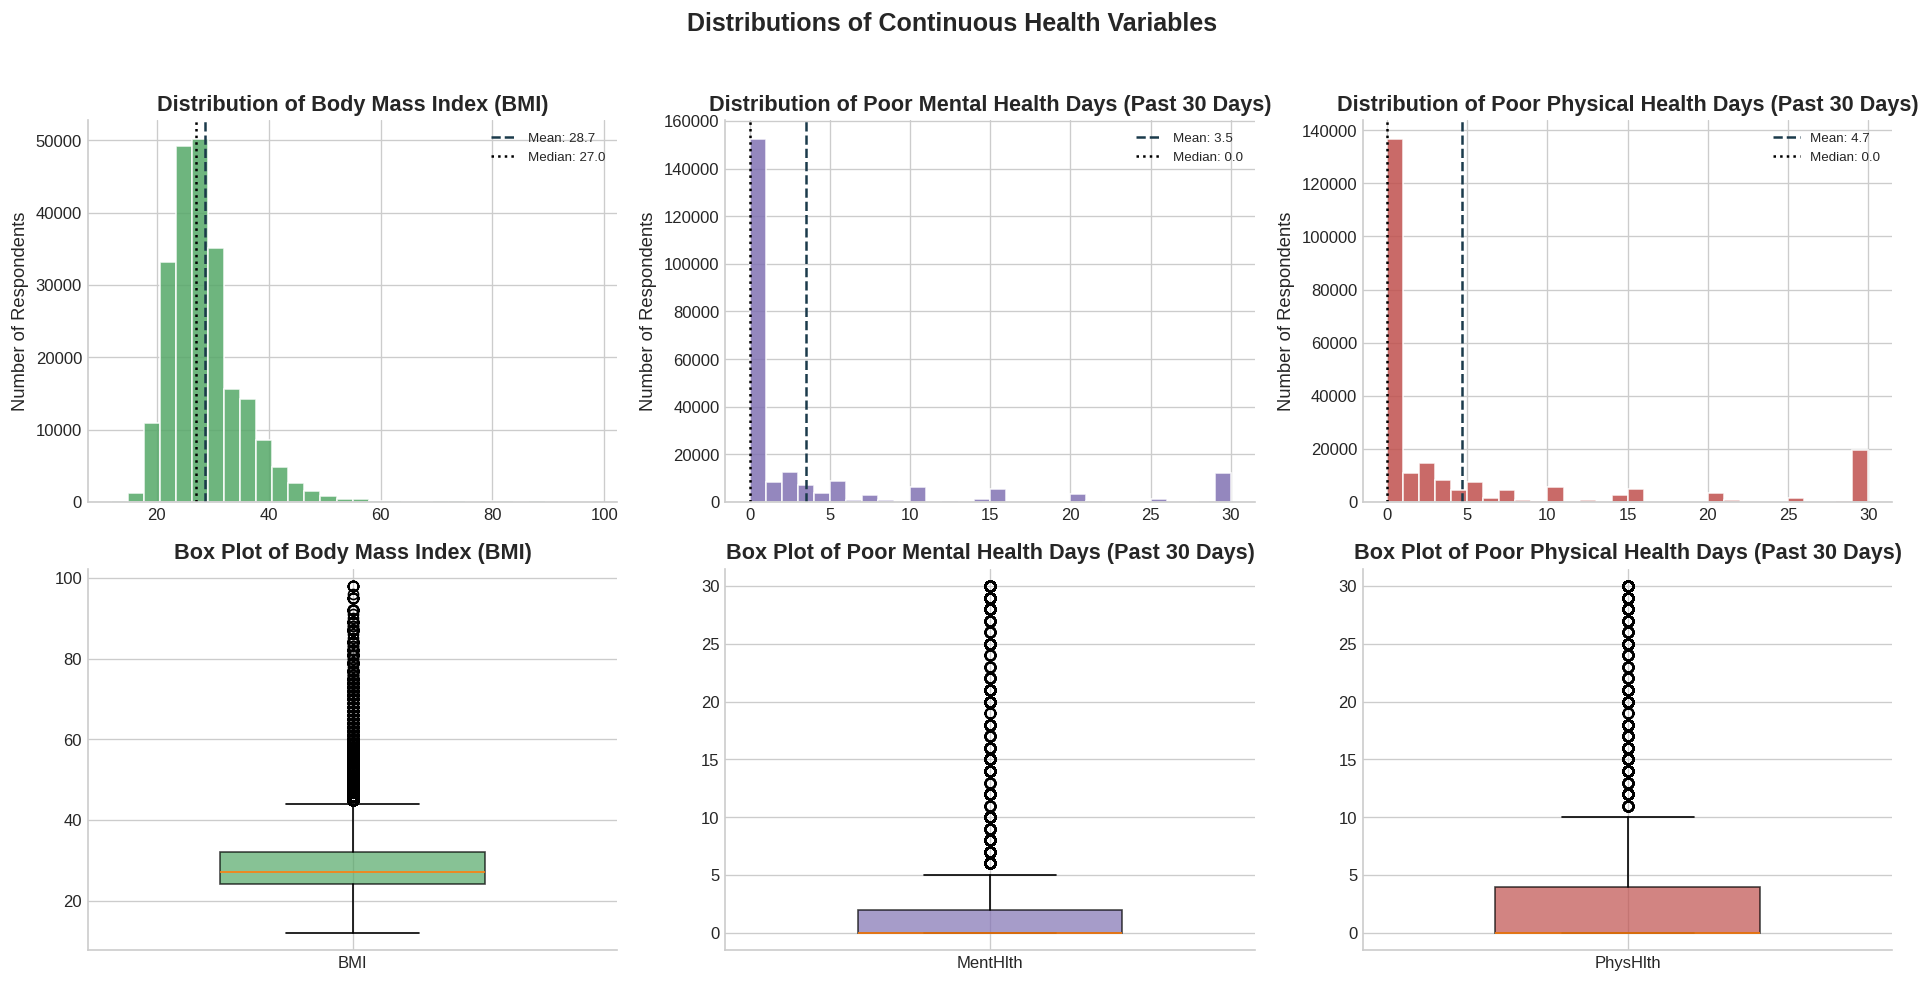

In [7]:
# List of continuous variables to visualize
continuous_columns = ['BMI', 'MentHlth', 'PhysHlth']
continuous_titles = ['Body Mass Index (BMI)', 'Poor Mental Health Days (Past 30 Days)', 'Poor Physical Health Days (Past 30 Days)']
continuous_colors = [teal_trust_palette['green'], teal_trust_palette['purple'], teal_trust_palette['coral']]

figure_continuous, axis_grid_continuous = plt.subplots(2, 3, figsize=(16, 8))

column_index = 0
while column_index < len(continuous_columns):

    current_column = continuous_columns[column_index]
    current_title = continuous_titles[column_index]
    current_color = continuous_colors[column_index]
    current_values = df[current_column]

    # Histogram on the top row
    axis_hist = axis_grid_continuous[0, column_index]
    axis_hist.hist(current_values, bins=30, color=current_color, edgecolor='white', alpha=0.85)

    mean_value = current_values.mean()
    median_value = current_values.median()
    axis_hist.axvline(mean_value, color=teal_trust_palette['navy'], linestyle='--', linewidth=1.5, label=f'Mean: {mean_value:.1f}')
    axis_hist.axvline(median_value, color='black', linestyle=':', linewidth=1.5, label=f'Median: {median_value:.1f}')
    axis_hist.set_title(f'Distribution of {current_title}')
    axis_hist.set_ylabel('Number of Respondents')
    axis_hist.legend(fontsize=8)
    axis_hist.spines['top'].set_visible(False)
    axis_hist.spines['right'].set_visible(False)

    # Box plot on the bottom row
    axis_box = axis_grid_continuous[1, column_index]
    box_result = axis_box.boxplot(current_values, vert=True, patch_artist=True, widths=0.5)
    for box_patch in box_result['boxes']:
        box_patch.set_facecolor(current_color)
        box_patch.set_alpha(0.7)
    axis_box.set_title(f'Box Plot of {current_title}')
    axis_box.set_xticklabels([current_column])
    axis_box.spines['top'].set_visible(False)
    axis_box.spines['right'].set_visible(False)

    column_index = column_index + 1

figure_continuous.suptitle('Distributions of Continuous Health Variables', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(visuals_dir, '04_continuous_histograms_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()

**Findings / Insights:**
- **BMI** has a mean of 28.7 and a median of 27.0 (overweight range), with a
  right-skewed distribution and a long tail of higher-BMI outliers, as the box plot's
  upper whisker and outlier points show.
- **MentHlth** (poor mental health days) has a median of 0 and a mean of 3.5 — most
  respondents report zero poor mental-health days, but a right-tail minority reports
  many, including a visible spike at 30 days (the maximum possible in the past-30-day
  window).
- **PhysHlth** (poor physical health days) shows the same pattern: a median of 0, a
  mean of 4.7, and a similar spike of respondents reporting the full 30 days.
- All three distributions are right-skewed, which is why the mean sits well above the
  median in each case, and why the box plots show many points flagged as outliers
  above the upper whisker.

## Section 4: Heatmaps & Correlation Plots

### Step 8: Correlation Matrix of Key Numeric Variables

**Why this is being done (Logic):**
A correlation heatmap lets us scan many variable relationships at once, rather than
checking pairs one by one. It shows both the strength (color intensity) and the
direction (positive or negative) of the linear relationship between each pair of
numeric variables, including the heart disease target itself.

**How it is being done (Code Explanation):**
- `correlation_columns`: A plain list of the numeric columns to include, covering the
  target variable, clinical risk factors, lifestyle factors, symptom-day variables,
  and age.
- `df[correlation_columns].corr()`: Computes the Pearson correlation coefficient
  between every pair of the selected columns.
- `sns.heatmap(...)`: Draws the correlation matrix as a color-coded grid, annotated
  with the numeric correlation values and using a diverging color map (`RdBu_r`) so
  positive and negative correlations are visually distinct.

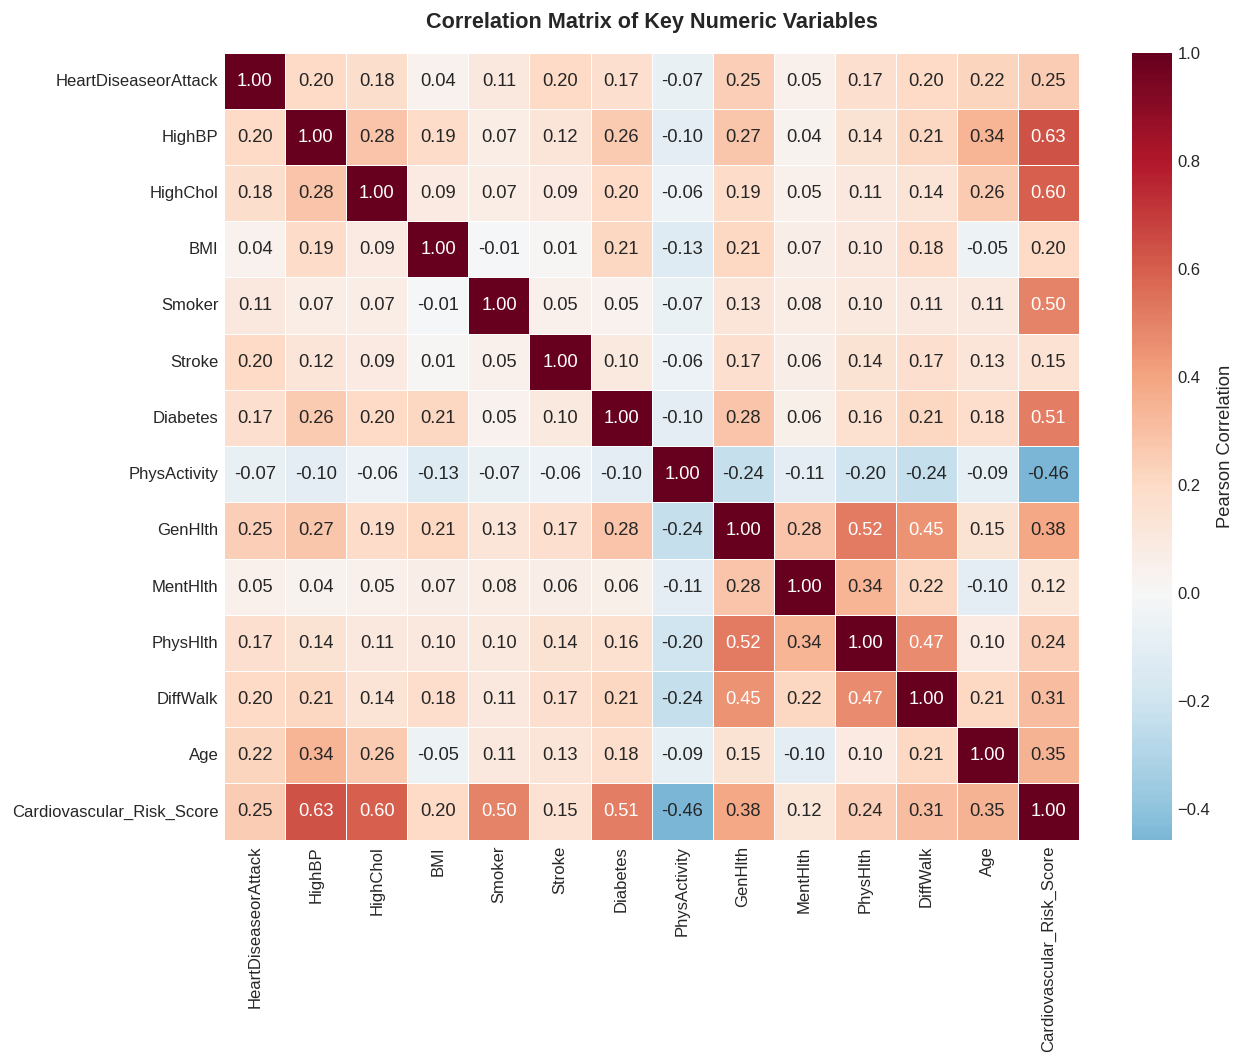

In [8]:
# Select key numeric variables for the correlation matrix
correlation_columns = ['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'BMI', 'Smoker', 'Stroke',
                        'Diabetes', 'PhysActivity', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Age',
                        'Cardiovascular_Risk_Score']

correlation_matrix = df[correlation_columns].corr()

figure_heatmap, axis_heatmap = plt.subplots(figsize=(11, 9))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=axis_heatmap, cbar_kws={'label': 'Pearson Correlation'})

axis_heatmap.set_title('Correlation Matrix of Key Numeric Variables', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(visuals_dir, '05_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

**Findings / Insights:**
- `Cardiovascular_Risk_Score` and `GenHlth` are tied as the strongest individual
  correlates of heart disease (r = 0.25 each), followed closely by `Age` (r = 0.22).
- `DiffWalk`, `HighBP`, and `Stroke` each correlate at r = 0.20, and `HighChol` and
  `Diabetes` follow close behind (r = 0.18 and 0.17).
- `PhysActivity` is the only negatively correlated variable in this set (r = -0.07),
  consistent with its protective role.
- `BMI` and `MentHlth` show the weakest individual correlations with heart disease
  (r = 0.04 and 0.05) despite being intuitive risk factors — a reminder that a
  variable can matter clinically without showing a strong linear correlation on its
  own.
- No single variable exceeds r = 0.25, reinforcing that heart disease risk in this
  dataset is multi-factorial rather than driven by one dominant predictor.

## Section 5: Scatter Plots — Investigating Relationships Between Variables

### Step 9: BMI vs. Total Unhealthy Days, and Age vs. Cardiovascular Risk Score

**Why this is being done (Logic):**
Scatter plots show the relationship between two continuous (or near-continuous)
variables at the individual-respondent level. Because this dataset has 229,781 rows
and most values are whole numbers, plotting every single point would produce a solid
overplotted block. To keep the scatter plot readable, we (1) draw a random sample of
respondents instead of the full dataset, (2) apply a low transparency (`alpha`) so
overlapping points are visible as denser regions, and (3) add a small amount of random
jitter to whole-number variables so repeated values do not stack exactly on top of
each other.

**How it is being done (Code Explanation):**
- `df.sample(n=..., random_state=42)`: Draws a fixed-size random sample so the plot
  renders quickly and stays readable, using a fixed `random_state` for reproducibility.
- `np.random.normal(0, jitter_amount, size=...)`: Generates small random offsets added
  to whole-number columns purely for display purposes (the underlying data is
  unchanged).
- `axis.scatter(...)`: Draws the points, colored by heart disease status using the
  `no_yes_palette`, with `alpha` set below 1 so overlapping points are visible.

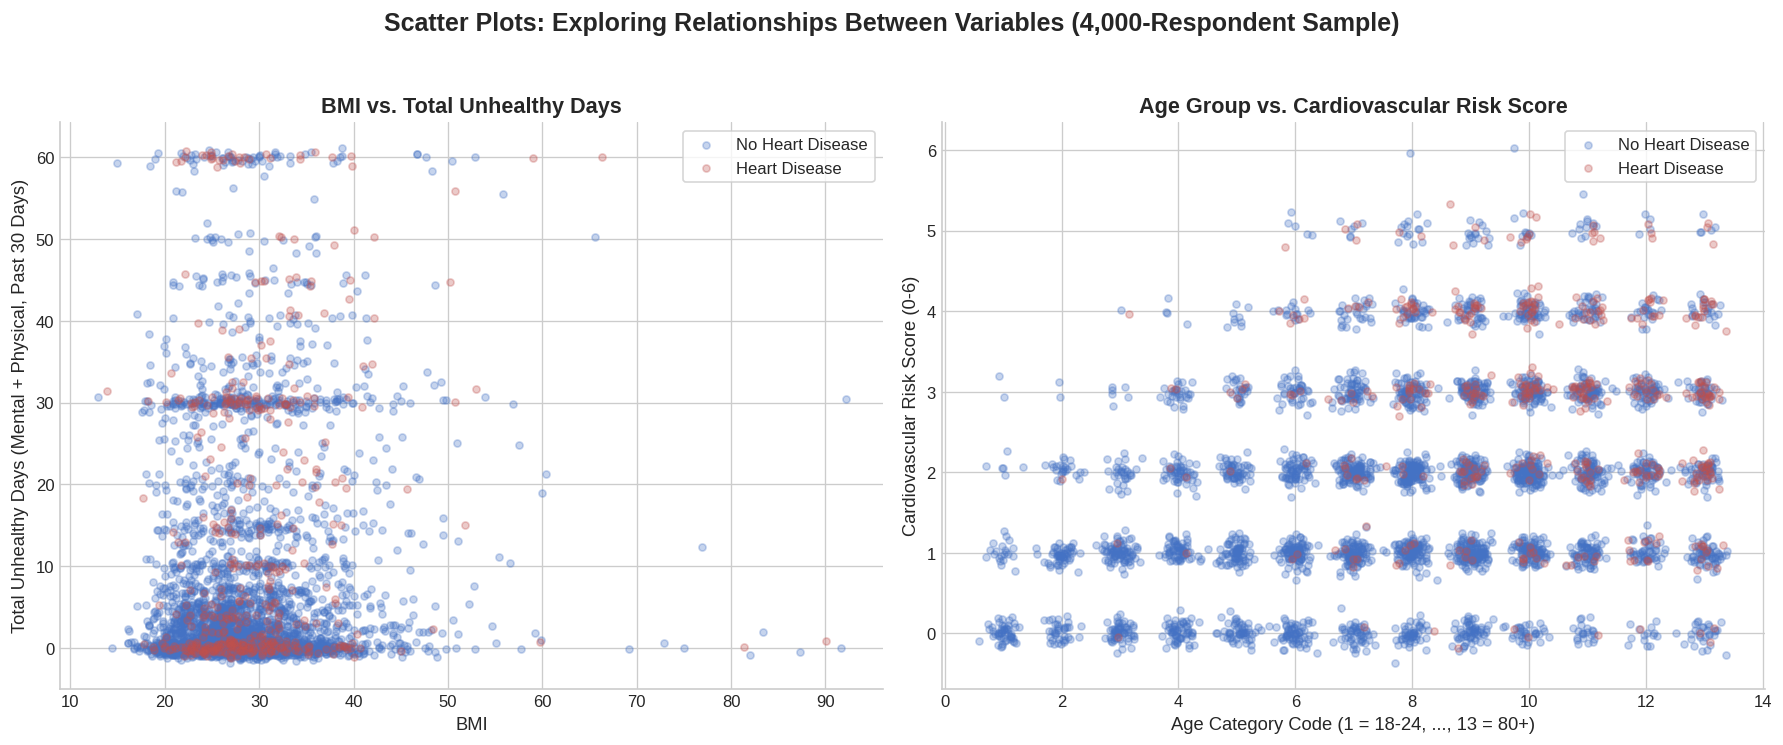

In [9]:
# Draw a fixed-size random sample for readable, reproducible scatter plots
scatter_sample = df.sample(n=4000, random_state=42).copy()

# Add small random jitter to whole-number columns so repeated values do not stack exactly
np.random.seed(42)
scatter_sample['BMI_jittered'] = scatter_sample['BMI'] + np.random.normal(0, 0.3, size=len(scatter_sample))
scatter_sample['Total_Unhealthy_Days_jittered'] = scatter_sample['Total_Unhealthy_Days'] + np.random.normal(0, 0.5, size=len(scatter_sample))
scatter_sample['Age_jittered'] = scatter_sample['Age'] + np.random.normal(0, 0.15, size=len(scatter_sample))
scatter_sample['Cardiovascular_Risk_Score_jittered'] = scatter_sample['Cardiovascular_Risk_Score'] + np.random.normal(0, 0.1, size=len(scatter_sample))

# Split the sample into No / Yes heart disease groups for separate scatter layers
no_disease_sample = scatter_sample[scatter_sample['Heart_Disease_or_Attack'] == 'No']
yes_disease_sample = scatter_sample[scatter_sample['Heart_Disease_or_Attack'] == 'Yes']

figure_scatter, axis_scatter_grid = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot 1: BMI vs Total Unhealthy Days
axis_scatter_1 = axis_scatter_grid[0]
axis_scatter_1.scatter(no_disease_sample['BMI_jittered'], no_disease_sample['Total_Unhealthy_Days_jittered'],
                        color=no_yes_palette[0], alpha=0.3, s=18, label='No Heart Disease')
axis_scatter_1.scatter(yes_disease_sample['BMI_jittered'], yes_disease_sample['Total_Unhealthy_Days_jittered'],
                        color=no_yes_palette[1], alpha=0.3, s=18, label='Heart Disease')
axis_scatter_1.set_title('BMI vs. Total Unhealthy Days')
axis_scatter_1.set_xlabel('BMI')
axis_scatter_1.set_ylabel('Total Unhealthy Days (Mental + Physical, Past 30 Days)')
axis_scatter_1.legend(frameon=True)
axis_scatter_1.spines['top'].set_visible(False)
axis_scatter_1.spines['right'].set_visible(False)

# Scatter plot 2: Age Code vs Cardiovascular Risk Score
axis_scatter_2 = axis_scatter_grid[1]
axis_scatter_2.scatter(no_disease_sample['Age_jittered'], no_disease_sample['Cardiovascular_Risk_Score_jittered'],
                        color=no_yes_palette[0], alpha=0.3, s=18, label='No Heart Disease')
axis_scatter_2.scatter(yes_disease_sample['Age_jittered'], yes_disease_sample['Cardiovascular_Risk_Score_jittered'],
                        color=no_yes_palette[1], alpha=0.3, s=18, label='Heart Disease')
axis_scatter_2.set_title('Age Group vs. Cardiovascular Risk Score')
axis_scatter_2.set_xlabel('Age Category Code (1 = 18-24, ..., 13 = 80+)')
axis_scatter_2.set_ylabel('Cardiovascular Risk Score (0-6)')
axis_scatter_2.legend(frameon=True)
axis_scatter_2.spines['top'].set_visible(False)
axis_scatter_2.spines['right'].set_visible(False)

figure_scatter.suptitle('Scatter Plots: Exploring Relationships Between Variables (4,000-Respondent Sample)', fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(visuals_dir, '06_scatter_plots.png'), dpi=150, bbox_inches='tight')
plt.show()

**Findings / Insights:**
- **BMI vs. Total Unhealthy Days**: The bulk of respondents (both groups) cluster at
  low unhealthy-day counts across the full BMI range, so there is no strong visual
  linear relationship — this matches BMI's weak correlation (r = 0.04) with heart
  disease seen in the heatmap. Heart disease points (coral) are somewhat denser in
  the BMI 25-35 band, but so is the overall sample.
- **Age vs. Cardiovascular Risk Score**: Coral (heart disease) points become visibly
  denser toward the older age codes (roughly 8 and above, corresponding to ages
  55+) and at higher risk scores (3+), while younger, lower-risk-score respondents
  are almost entirely blue — a visual confirmation that age and comorbidity count
  compound together.

## Section 6: Line Plots — Trends Across Ordered Categories

### Step 10: Heart Disease Prevalence by Age Category and by Risk Factor Count

**Why this is being done (Logic):**
`Age_Category` and `Cardiovascular_Risk_Score` are both naturally ordered variables
(age brackets from youngest to oldest; risk factor count from 0 to 6). Line plots are
well suited to ordered categories because the connecting line visually emphasizes the
trend — in this case, whether heart disease prevalence rises steadily as age or risk
factor count increases.

**How it is being done (Code Explanation):**
- `df.groupby('Age_Category')['HeartDiseaseorAttack'].mean()`: Calculates the heart
  disease prevalence rate (the average of the 0/1 target column) within each age
  category, since the mean of a 0/1 column is exactly the proportion of 1s.
- `age_order`: A manually defined list that puts the age categories in their natural
  chronological order before plotting, since Pandas would otherwise sort them
  alphabetically (e.g. placing `'80+'` before `'18-24'`).
- `axis.plot(..., marker='o')`: Draws the line chart with a marker at each data point
  and an annotated percentage label above each marker.

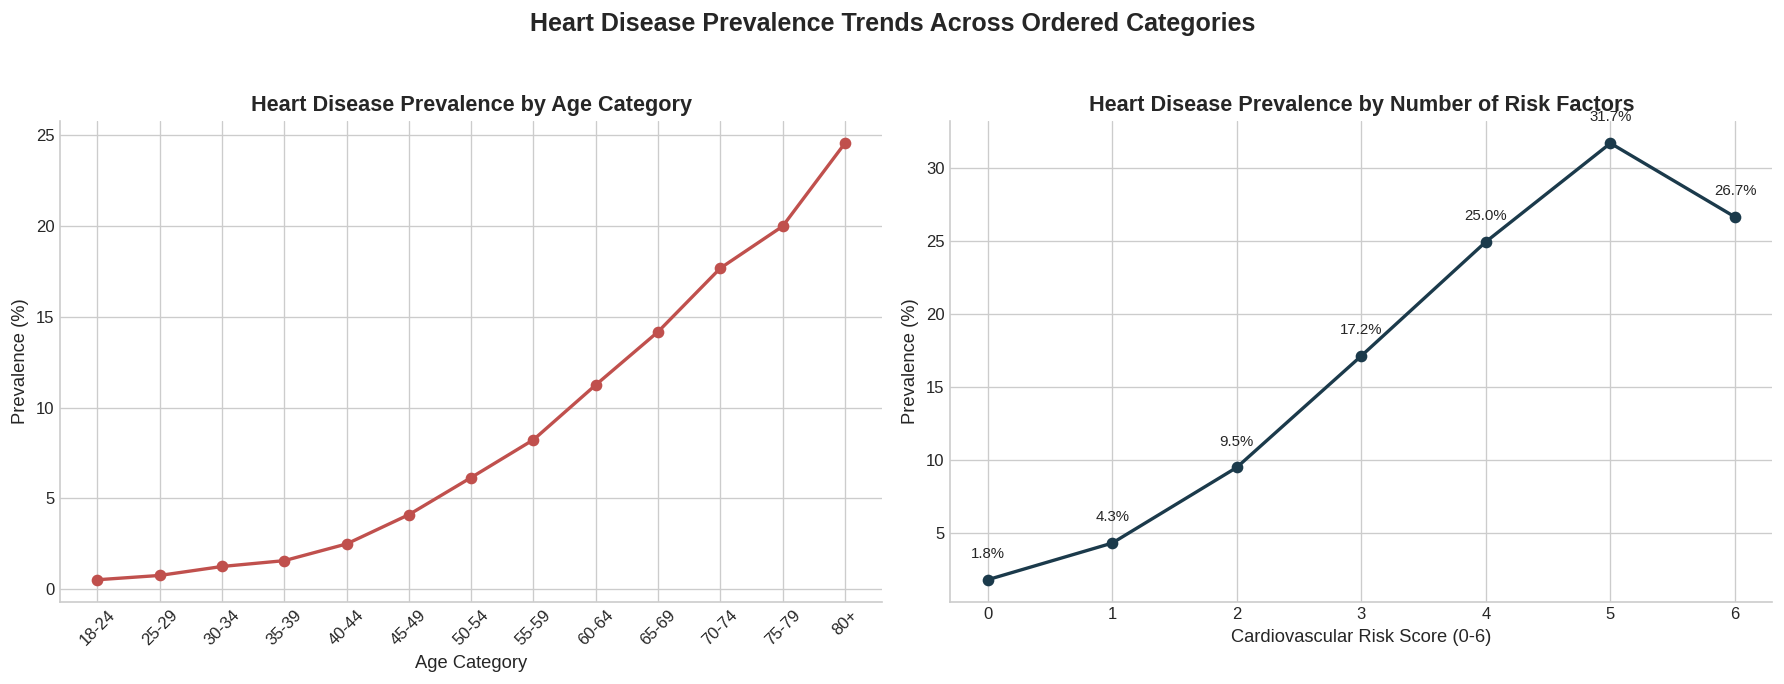

In [10]:
# Define the natural chronological order of age categories
age_order = ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59',
             '60-64', '65-69', '70-74', '75-79', '80+']

# Calculate heart disease prevalence (%) within each age category, then reorder chronologically
prevalence_by_age = df.groupby('Age_Category')['HeartDiseaseorAttack'].mean() * 100
prevalence_by_age = prevalence_by_age.reindex(age_order)

# Calculate heart disease prevalence (%) within each risk factor count (already numeric and ordered)
prevalence_by_risk_score = df.groupby('Cardiovascular_Risk_Score')['HeartDiseaseorAttack'].mean() * 100
prevalence_by_risk_score = prevalence_by_risk_score.sort_index()

figure_line, axis_line_grid = plt.subplots(1, 2, figsize=(15, 5.5))

# Line plot 1: Prevalence by age category
axis_line_1 = axis_line_grid[0]
axis_line_1.plot(age_order, prevalence_by_age.values, marker='o', color=teal_trust_palette['coral'], linewidth=2)
axis_line_1.set_title('Heart Disease Prevalence by Age Category')
axis_line_1.set_xlabel('Age Category')
axis_line_1.set_ylabel('Prevalence (%)')
axis_line_1.tick_params(axis='x', rotation=45)
axis_line_1.spines['top'].set_visible(False)
axis_line_1.spines['right'].set_visible(False)

# Line plot 2: Prevalence by cardiovascular risk score
axis_line_2 = axis_line_grid[1]
axis_line_2.plot(prevalence_by_risk_score.index, prevalence_by_risk_score.values, marker='o',
                  color=teal_trust_palette['navy'], linewidth=2)
axis_line_2.set_title('Heart Disease Prevalence by Number of Risk Factors')
axis_line_2.set_xlabel('Cardiovascular Risk Score (0-6)')
axis_line_2.set_ylabel('Prevalence (%)')
axis_line_2.set_xticks(prevalence_by_risk_score.index)
axis_line_2.spines['top'].set_visible(False)
axis_line_2.spines['right'].set_visible(False)

# Add percentage labels above each marker on both line plots
risk_score_index = 0
while risk_score_index < len(prevalence_by_risk_score):
    axis_line_2.text(prevalence_by_risk_score.index[risk_score_index],
                      prevalence_by_risk_score.values[risk_score_index] + 1.5,
                      f'{prevalence_by_risk_score.values[risk_score_index]:.1f}%', ha='center', fontsize=9)
    risk_score_index = risk_score_index + 1

figure_line.suptitle('Heart Disease Prevalence Trends Across Ordered Categories', fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(visuals_dir, '07_line_plots_prevalence_trends.png'), dpi=150, bbox_inches='tight')
plt.show()

**Findings / Insights:**
- **Age category**: Prevalence rises from 0.5% at ages 18-24 to 24.6% at ages 80+ — a
  roughly 49x increase across the age range, with the line curving upward rather than
  rising in a straight line, meaning risk accelerates faster in the older brackets
  than the younger ones.
- **Cardiovascular risk score**: Prevalence rises steadily from 1.8% with zero risk
  factors to a peak of 31.7% at 5 risk factors, before dipping slightly to 26.7% at
  all 6 risk factors present — likely reflecting the much smaller number of
  respondents who have all six risk factors simultaneously, making that final point
  noisier than the rest of the trend.
- Both trends confirm that age and comorbidity count are strong, ordered, dose-response
  drivers of heart disease risk in this dataset.

## Section 7: Violin Plots — Distribution Shape by Heart Disease Status

### Step 11: BMI, Physical Health Days, and Age by Heart Disease Status

**Why this is being done (Logic):**
A violin plot combines a box plot's summary statistics (median, quartiles) with a
mirrored density curve showing the full shape of the distribution. This makes it
possible to see, for example, whether the BMI distribution among heart disease
respondents is simply shifted higher, or whether it is shaped differently (e.g. more
spread out, bimodal) compared to respondents without heart disease.

**How it is being done (Code Explanation):**
- `violin_columns`: A plain list of the three variables to compare by heart disease
  status.
- We build a 1-row x 3-column figure, one violin plot per variable.
- `sns.violinplot(...)`: Draws the violin plot with `x='Heart_Disease_or_Attack'` so
  the two groups (No / Yes) appear side by side, using the `no_yes_palette` colors.

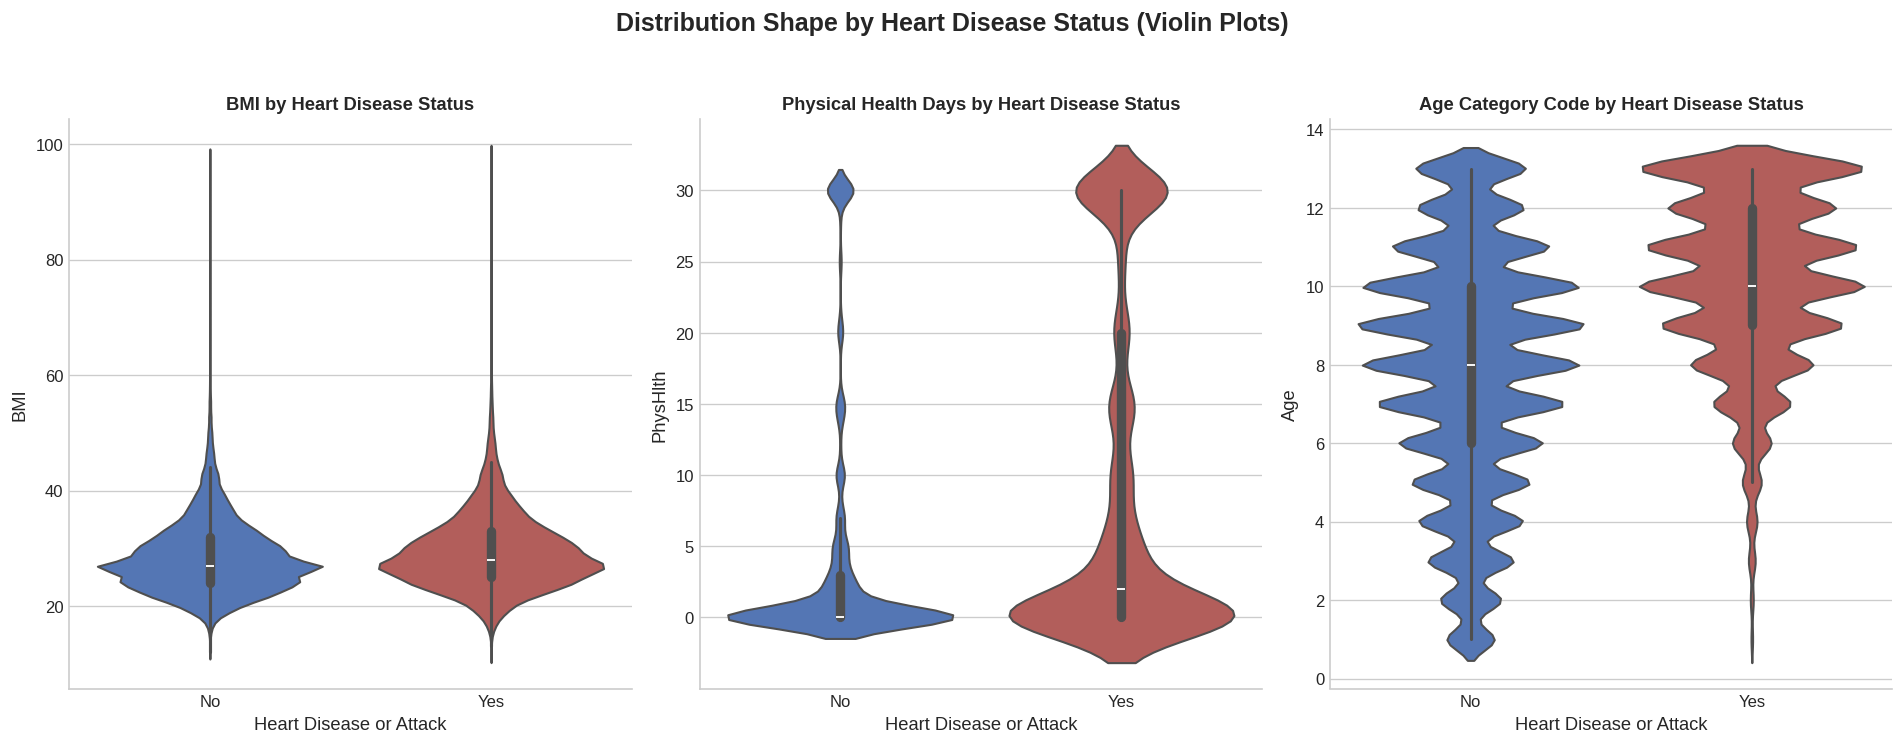

In [11]:
# List of variables to compare by heart disease status using violin plots
violin_columns = ['BMI', 'PhysHlth', 'Age']
violin_titles = ['BMI by Heart Disease Status', 'Physical Health Days by Heart Disease Status', 'Age Category Code by Heart Disease Status']

figure_violin, axis_violin_grid = plt.subplots(1, 3, figsize=(16, 6))

column_index = 0
while column_index < len(violin_columns):

    current_column = violin_columns[column_index]
    current_title = violin_titles[column_index]
    axis_violin = axis_violin_grid[column_index]

    sns.violinplot(data=df, x='Heart_Disease_or_Attack', y=current_column, order=['No', 'Yes'],
                    palette=no_yes_palette, ax=axis_violin)

    axis_violin.set_title(current_title, fontsize=11)
    axis_violin.set_xlabel('Heart Disease or Attack')
    axis_violin.set_ylabel(current_column)
    axis_violin.spines['top'].set_visible(False)
    axis_violin.spines['right'].set_visible(False)

    column_index = column_index + 1

figure_violin.suptitle('Distribution Shape by Heart Disease Status (Violin Plots)', fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(visuals_dir, '08_violin_plots.png'), dpi=150, bbox_inches='tight')
plt.show()

**Findings / Insights:**
- **BMI**: The median is only one point higher for the heart disease group (28.0 vs.
  27.0), and the two violin shapes overlap heavily — BMI alone does not separate the
  groups sharply, consistent with its weak correlation seen earlier.
- **Physical Health Days**: The heart disease group's violin is visibly wider and
  pulled toward higher values (median 2.0 days vs. 0.0 days for the no-disease
  group), showing that respondents with heart disease report meaningfully more poor
  physical-health days.
- **Age**: The heart disease group's violin is shifted noticeably toward older age
  codes (median age code 10, i.e. 65-69, vs. median code 8, i.e. 55-59, for the
  no-disease group), visually reinforcing age as one of the strongest demographic
  drivers of heart disease in this dataset.

## Section 8: Pair Plots — Pairwise Relationships Across Multiple Variables

### Step 12: Pairwise Relationships Among Key Clinical & Demographic Variables

**Why this is being done (Logic):**
A pair plot shows every pairwise scatter plot combination for a set of variables at
once, with each variable's own distribution shown along the diagonal. This gives a
single, compact view of how BMI, symptom days, age, and risk factor count relate to
each other, and how those relationships differ between respondents with and without
heart disease.

**How it is being done (Code Explanation):**
- `pairplot_columns`: A plain list of five variables kept small on purpose, since a
  pair plot's size grows quickly with the number of variables.
- `df.sample(n=..., random_state=42)`: As with the scatter plots, we sample the
  dataset so the pair plot renders in a reasonable amount of time and stays readable.
- `sns.pairplot(...)`: Builds the full grid of scatter plots and diagonal histograms,
  colored by `Heart_Disease_or_Attack` using the `no_yes_palette`.

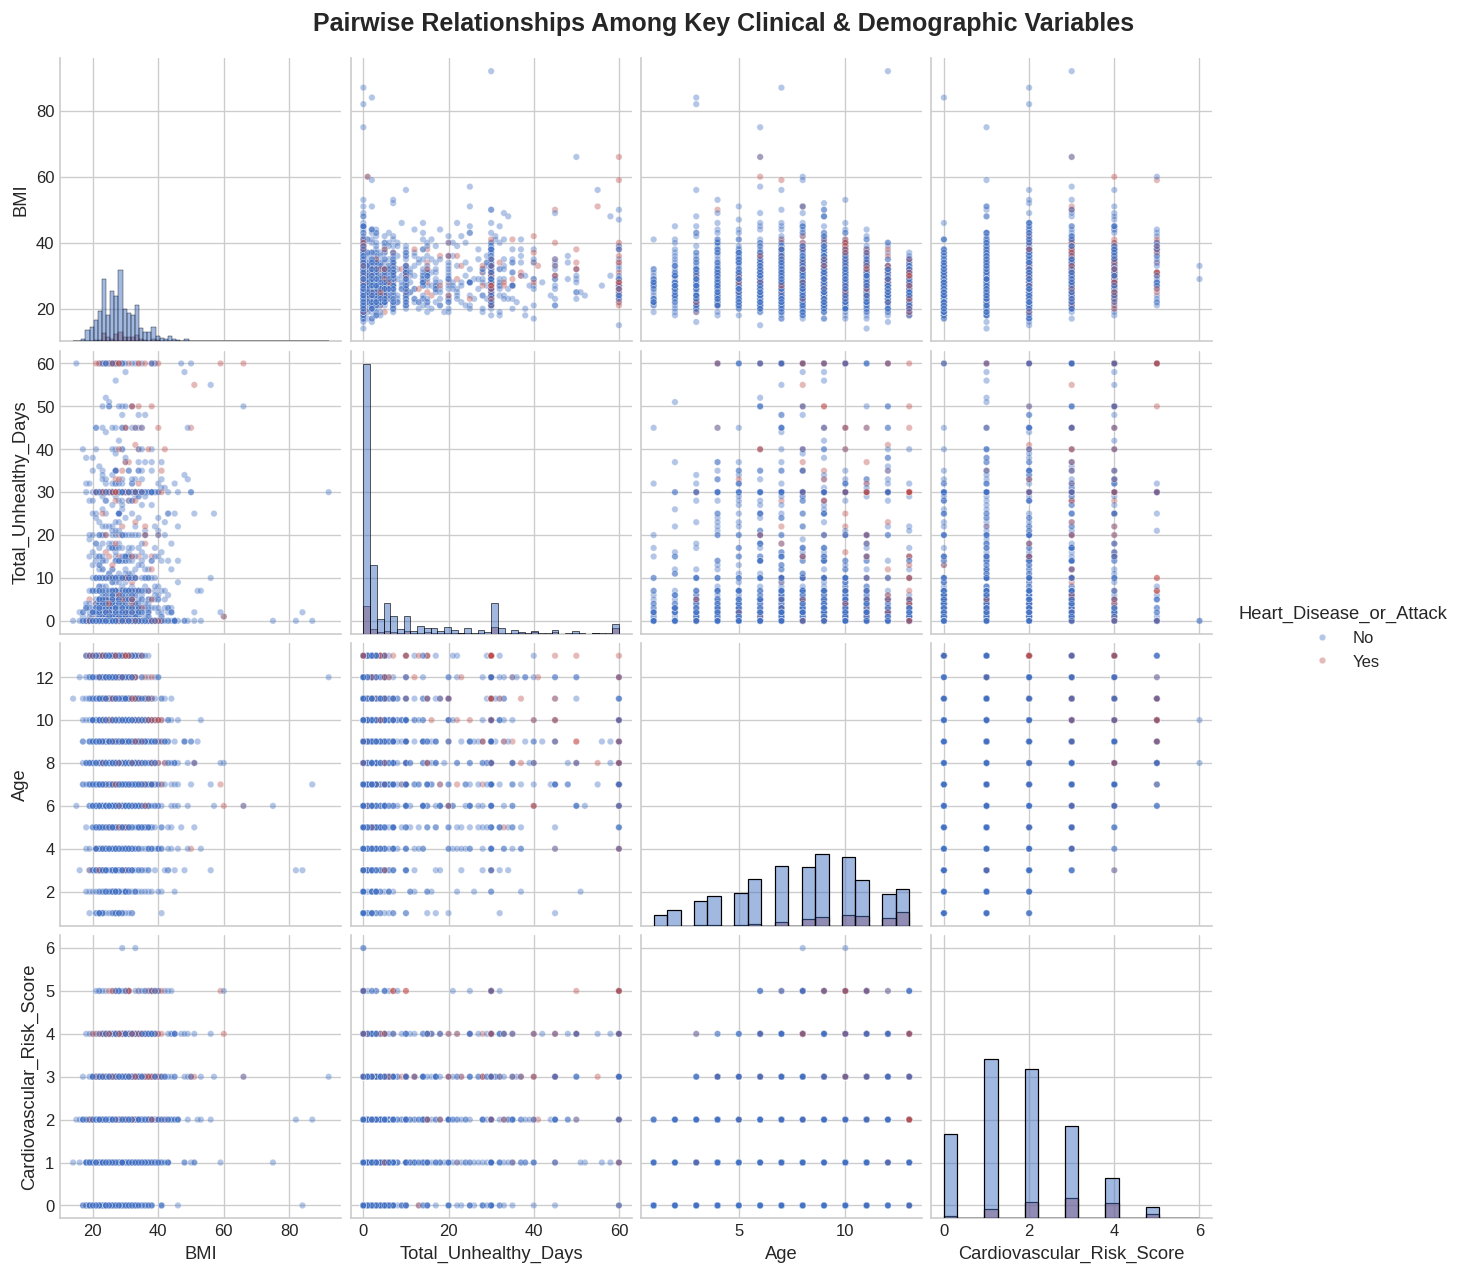

In [12]:
# Select a small set of key variables for the pair plot
pairplot_columns = ['BMI', 'Total_Unhealthy_Days', 'Age', 'Cardiovascular_Risk_Score', 'Heart_Disease_or_Attack']

# Draw a fixed-size random sample so the pair plot renders in a reasonable amount of time
pairplot_sample = df[pairplot_columns].sample(n=2000, random_state=42)

pairplot_grid = sns.pairplot(pairplot_sample, hue='Heart_Disease_or_Attack', hue_order=['No', 'Yes'],
                              palette=no_yes_palette, diag_kind='hist', plot_kws={'alpha': 0.4, 's': 15},
                              height=2.6)

pairplot_grid.figure.suptitle('Pairwise Relationships Among Key Clinical & Demographic Variables', fontweight='bold', y=1.02)
pairplot_grid.savefig(os.path.join(visuals_dir, '09_pair_plot.png'), dpi=150, bbox_inches='tight')
plt.show()

**Findings / Insights:**
- The diagonal histograms confirm the earlier findings at a glance: `BMI` is
  right-skewed around the high-20s, `Total_Unhealthy_Days` is heavily concentrated
  near zero with a long tail, `Age` skews toward the older brackets, and
  `Cardiovascular_Risk_Score` peaks around 1-2 risk factors.
- In the `Age` vs. `Cardiovascular_Risk_Score` panel, coral (heart disease) points
  concentrate in the upper-right region — older respondents with more risk factors —
  echoing the same pattern seen in the earlier scatter plot.
- No pairwise panel shows a single clean linear relationship; the scatter clouds are
  broad and overlapping in every combination, visually reinforcing that heart disease
  risk here is multi-factorial rather than driven by any one pairwise relationship.